--- معلومات البيانات ---
عدد الصفوف: 69608
عدد الأعمدة: 20

--- القيم المفقودة ---
order_approved_at                 112
order_delivered_carrier_date     1256
order_delivered_customer_date    2096
total_items                       540
total_price                       540
total_freight                     540
sellers_count                     540
total_payment_value                 1
payment_types_count                 1
max_installments                    1
dtype: int64


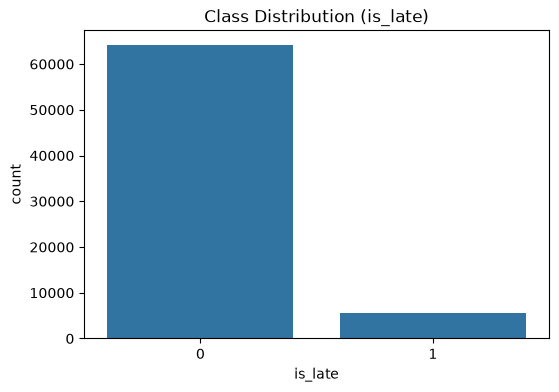

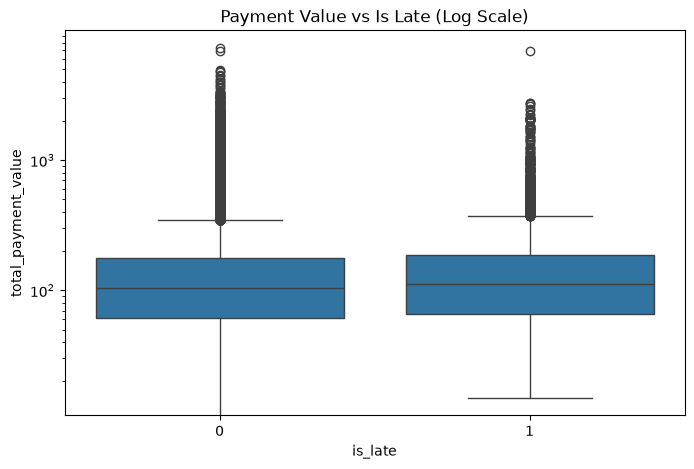

تم الانتهاء من الـ EDA وحفظ الرسم البياني بنجاح!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. قراءة بيانات الـ Train فقط
train_df = pd.read_parquet("../artifacts/train.parquet")

# إنشاء مجلد للرسومات
os.makedirs("../artifacts/plots", exist_ok=True)

# 2. طباعة المعلومات الأساسية
print("--- معلومات البيانات ---")
print(f"عدد الصفوف: {len(train_df)}")
print(f"عدد الأعمدة: {len(train_df.columns)}")

print("\n--- القيم المفقودة ---")
missing = train_df.isnull().sum()
print(missing[missing > 0])

# 3. رسم وتوزيع المتغير الهدف
plt.figure(figsize=(6, 4))
sns.countplot(x="is_late", data=train_df)
plt.title("Class Distribution (is_late)")
plt.savefig("../artifacts/plots/target_distribution.png")
plt.show()  # إظهار الرسمة مباشرة بالنوتبوك

# 4. رسم العلاقة بين قيمة الدفع والتأخير
plt.figure(figsize=(8, 5))
sns.boxplot(x="is_late", y="total_payment_value", data=train_df)
plt.yscale("log")
plt.title("Payment Value vs Is Late (Log Scale)")
plt.savefig("../artifacts/plots/payment_vs_late.png")
plt.show()  # إظهار الرسمة مباشرة بالنوتبوك

print("تم الانتهاء من الـ EDA وحفظ الرسم البياني بنجاح!")